# Spam Detection — Static vs. Synthetic Evaluation

This notebook compares two evaluation approaches:
- **Static**: 300 real samples from the shared SMS Spam benchmark CSV (150 HAM + 150 SPAM)
- **Synthetic**: Results from the GET pipeline (Generate → Evaluate → Trash)

**Hypothesis**: If models score higher on real data than on synthetic data, this suggests data leakage — the models may have seen the real benchmark data during training.

## Setup

In [1]:
import sys
import os

# Add project root to path so we can import framework modules
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

Project root: c:\Users\nikla\Dokumente\Master\FSS2026_lokal\live-eval


## Load Models

In [2]:
from framework.models.spam.roberta import RobertaSpamModel

MSHENODA_CONFIG = {
    "name": "mshenoda/roberta-spam",
    "type": "roberta",
    "max_length": 128,
    "label_map": {"LABEL_0": "HAM", "LABEL_1": "SPAM"}
}

MARIAGRANDURY_CONFIG = {
    "name": "mariagrandury/roberta-base-finetuned-sms-spam-detection",
    "type": "roberta",
    "max_length": 128,
    "label_map": {"LABEL_0": "HAM", "LABEL_1": "SPAM"}
}

print("Loading models...")
mshenoda      = RobertaSpamModel(MSHENODA_CONFIG)
mariagrandury = RobertaSpamModel(MARIAGRANDURY_CONFIG)
print("All models loaded.")

c:\Users\nikla\anaconda3\envs\gec_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading models...
Loading model: mshenoda/roberta-spam ...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2545.66it/s]
RobertaForSequenceClassification LOAD REPORT from: mshenoda/roberta-spam
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded mshenoda/roberta-spam.
Loading model: mariagrandury/roberta-base-finetuned-sms-spam-detection ...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2194.73it/s]
RobertaForSequenceClassification LOAD REPORT from: mariagrandury/roberta-base-finetuned-sms-spam-detection
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded mariagrandury/roberta-base-finetuned-sms-spam-detection.
All models loaded.


## Static Evaluation
Load all 300 samples from the shared SMS Spam benchmark CSV (150 HAM + 150 SPAM) and evaluate both models.

In [3]:
import csv

csv_path = os.path.join(project_root, "framework", "data", "spam", "sms_spam_sample_300.csv")
static_samples = []

with open(csv_path, encoding="utf-8", newline="") as f:
    for row in csv.DictReader(f):
        label = row["label"].upper()  # CSV uses HAM / SPAM
        text  = row["text"].strip()
        if text and label in ("HAM", "SPAM"):
            static_samples.append({"text": text, "label": label})

ham_count  = sum(1 for s in static_samples if s["label"] == "HAM")
spam_count = sum(1 for s in static_samples if s["label"] == "SPAM")
print(f"Loaded {ham_count} HAM + {spam_count} SPAM = {len(static_samples)} samples from CSV.")

Loaded 150 HAM + 150 SPAM = 300 samples from CSV.


In [4]:
from framework.evaluators.classification.accuracy  import compute_accuracy
from framework.evaluators.classification.precision import compute_precision
from framework.evaluators.classification.recall    import compute_recall
from framework.evaluators.classification.f1        import compute_f1

def evaluate_model(model, samples):
    texts       = [s["text"]  for s in samples]
    predictions = model.predict(texts)
    results     = [
        {"prediction": pred, "label": s["label"]}
        for pred, s in zip(predictions, samples)
    ]
    return {
        "accuracy":  compute_accuracy(results),
        "precision": compute_precision(results, positive_label="SPAM"),
        "recall":    compute_recall(results,    positive_label="SPAM"),
        "f1":        compute_f1(results,        positive_label="SPAM"),
    }

print("Evaluating mshenoda/roberta-spam on static data...")
static_mshenoda = evaluate_model(mshenoda, static_samples)
print(f"  {static_mshenoda}")

print("Evaluating mariagrandury/roberta on static data...")
static_mariagrandury = evaluate_model(mariagrandury, static_samples)
print(f"  {static_mariagrandury}")

Evaluating mshenoda/roberta-spam on static data...
  {'accuracy': 0.9966666666666667, 'precision': 1.0, 'recall': 0.9933333333333333, 'f1': 0.9966555183946488}
Evaluating mariagrandury/roberta on static data...
  {'accuracy': 0.9933333333333333, 'precision': 0.9933333333333333, 'recall': 0.9933333333333333, 'f1': 0.9933333333333333}


## Synthetic Evaluation
Load the GET pipeline results from `results.json`.

In [5]:
import json

results_path = os.path.join(project_root, "results.json")
with open(results_path, encoding="utf-8") as f:
    get_results = json.load(f)

MSHENODA_KEY      = "mshenoda/roberta-spam"
MARIAGRANDURY_KEY = "mariagrandury/roberta-base-finetuned-sms-spam-detection"

# Extract mean scores
synthetic_mshenoda      = {k: v["mean"] for k, v in get_results[MSHENODA_KEY].items()}
synthetic_mariagrandury = {k: v["mean"] for k, v in get_results[MARIAGRANDURY_KEY].items()}

print("GET results (mshenoda):      ", synthetic_mshenoda)
print("GET results (mariagrandury): ", synthetic_mariagrandury)

GET results (mshenoda):       {'accuracy': 0.7718, 'precision': 1.0, 'recall': 0.7181, 'f1': 0.835, 'fpr': 0.0}
GET results (mariagrandury):  {'accuracy': 0.7651, 'precision': 0.9956, 'recall': 0.7118, 'f1': 0.8289, 'fpr': 0.0104}


## Comparison

In [6]:
import pandas as pd

metrics = ["accuracy", "precision", "recall", "f1"]

df = pd.DataFrame({
    "mshenoda (static 300)": [static_mshenoda[m] for m in metrics],
    "mshenoda (synthetic)": [synthetic_mshenoda.get(m, float("nan")) for m in metrics],
    "mariagrandury (static 300)": [static_mariagrandury[m] for m in metrics],
    "mariagrandury (synthetic)": [synthetic_mariagrandury.get(m, float("nan")) for m in metrics],
}, index=metrics)

print(df.round(4).to_string())

           mshenoda (static 300)  mshenoda (synthetic)  mariagrandury (static 300)  mariagrandury (synthetic)
accuracy                  0.9967                0.7718                      0.9933                     0.7651
precision                 1.0000                1.0000                      0.9933                     0.9956
recall                    0.9933                0.7181                      0.9933                     0.7118
f1                        0.9967                0.8350                      0.9933                     0.8289


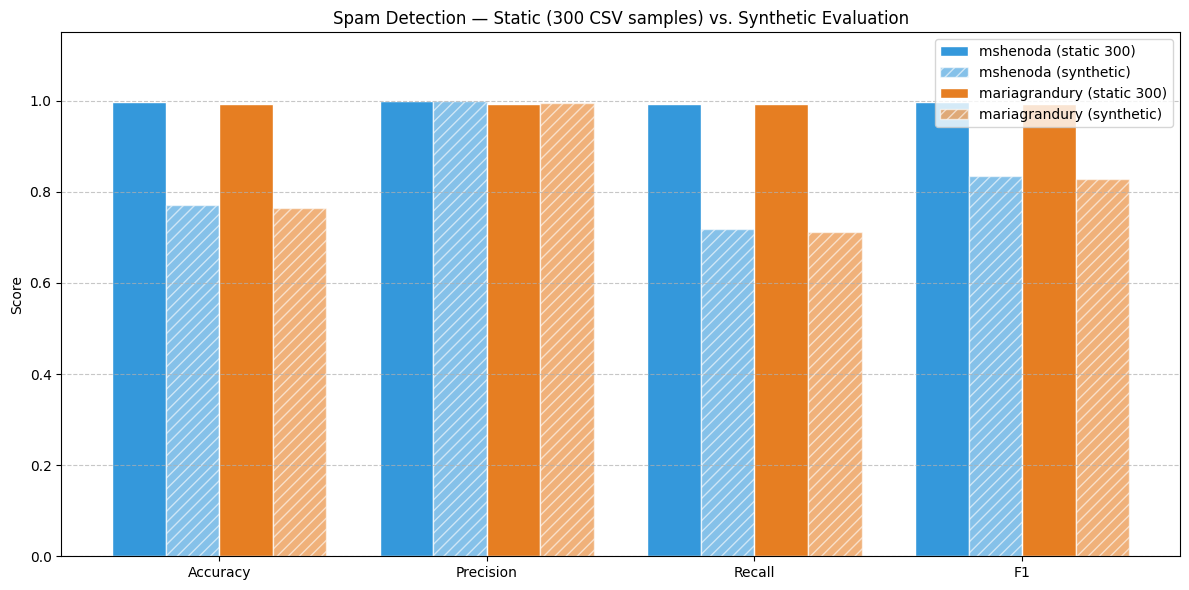

Plot saved to spam_static_vs_synthetic.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

x     = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - 1.5*width, [static_mshenoda[m]                        for m in metrics], width, label="mshenoda (static 300)",         color="#3498db", edgecolor="white")
ax.bar(x - 0.5*width, [synthetic_mshenoda.get(m, 0)              for m in metrics], width, label="mshenoda (synthetic)",           color="#3498db", edgecolor="white", hatch="///", alpha=0.6)
ax.bar(x + 0.5*width, [static_mariagrandury[m]                   for m in metrics], width, label="mariagrandury (static 300)",     color="#e67e22", edgecolor="white")
ax.bar(x + 1.5*width, [synthetic_mariagrandury.get(m, 0)         for m in metrics], width, label="mariagrandury (synthetic)",     color="#e67e22", edgecolor="white", hatch="///", alpha=0.6)

ax.set_ylabel("Score")
ax.set_title("Spam Detection — Static (300 CSV samples) vs. Synthetic Evaluation")
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylim(0, 1.15)
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.7)

fig.tight_layout()
plt.savefig("spam_static_vs_synthetic.png", dpi=150)
plt.show()
print("Plot saved to spam_static_vs_synthetic.png")

## Interpretation

The GET pipeline (synthetic evaluation) serves as a leakage-free baseline — generated examples
are fresh each run and cannot have been seen during model training.

If static scores are **higher** than synthetic scores, this supports the **data leakage hypothesis**:
the model has likely been exposed to this or a similar benchmark dataset during training, causing
it to overperform on real data.

## Conclusion

Traditional static benchmarking (using real dataset samples directly) risks overestimating model
performance when the model has already seen similar data during training. The GET pipeline provides
a controlled alternative that measures true generalization on unseen synthetic data.